# Visualizations

#### Overview

We shall focus on visualizing measurement outcome counts, quantum states, circuits, devices etc.

Use `!pip install 'qiskit[visualization]` to use visualization functions.

The following example uses some common functions that were created by Matplotlib

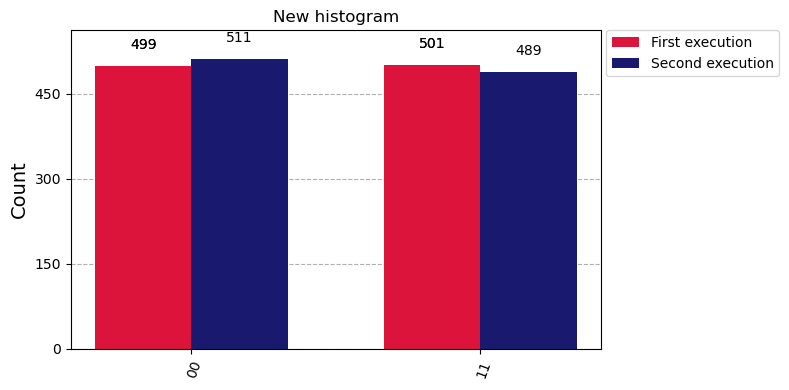

In [1]:
from qiskit.visualization import plot_histogram

counts1 = {'00': 499, '11': 501}
counts2 = {'00': 511, '11': 489}
data = [counts1, counts2]

legend = ['First execution', 'Second execution']
title = 'New histogram'
figsize = (8,4)
color=['crimson','midnightblue']

plot_histogram(data, legend=legend, title=title, figsize=figsize, color=color)

In [2]:
# functions of plot_histogram
plot_histogram

<function qiskit.visualization.counts_visualization.plot_histogram(data, figsize=None, color=None, number_to_keep=None, sort='asc', target_string=None, legend=None, bar_labels=True, title=None, ax=None, filename=None)>

In [3]:
# Saving the figure to file

# 1. passing filename to filename kwarg
plot_histogram(data, filename='new_hist.png')

# 2. matplot.figure.Figure.savefig() method
hist = plot_histogram(data)
hist.savefig('new_hist.png')

#### Counts Visualizations - visualize measurement outcome counts

`plot_histogram` is used to plot a histogram of input counts data

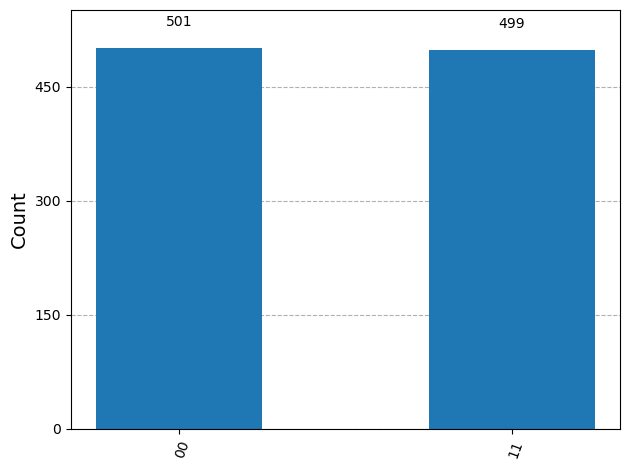

In [4]:
# Dictionary method with keys as bitstrings and values as counts

counts = {"00": 501, "11": 499}
plot_histogram(counts)

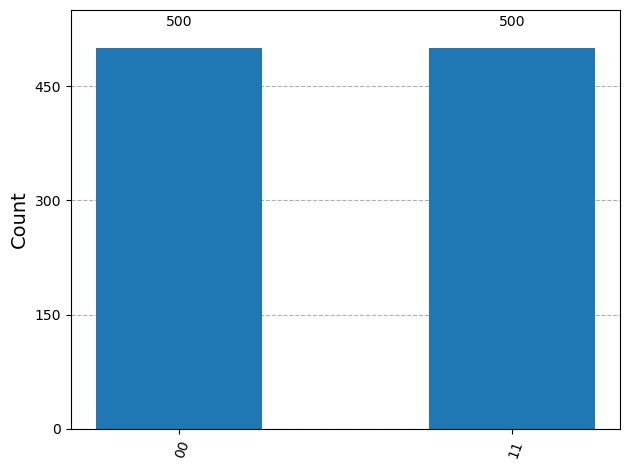

In [5]:
# Create a counts object obtained from get_counts()

from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Construct a bell state and measure
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

# Choose simulator
backend = Aer.get_backend("qasm_simulator")

# Run circuit
compiled = transpile(qc, backend)
result = backend.run(compiled, shots=1000).result()

# Get counts
counts = result.get_counts()

# Plot histogram
plot_histogram(counts)


#### Distribution Visualization - visualize sampled distribution

`plot_distribution` is used to plot a distribution from input sampled data

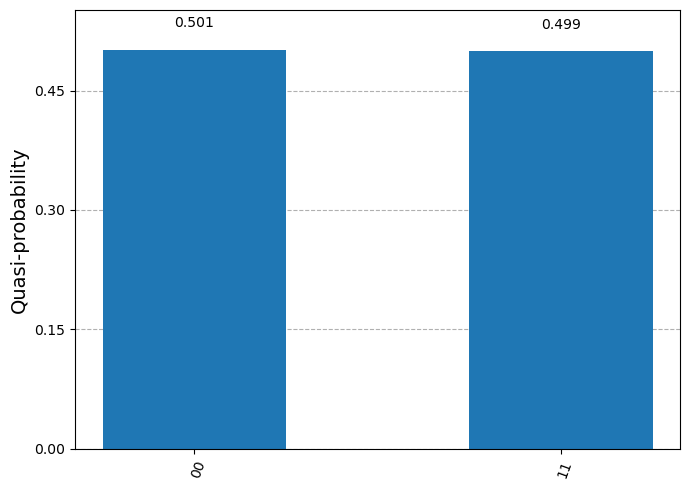

In [6]:
from qiskit.visualization import plot_distribution

counts = {"00": 501, "11": 499}
plot_distribution(counts)

#### State Visualization - visualize quantum states

`plot_bloch_vector` - plot bloch sphere

`plot_bloch_multivector` - plot bloch sphere for each qubit

`plot_state_city` - plot cityscape of quantum state

`plot_state_hinton` - plot hinton diagram for density matrix of quantum state

`plot_state_paulivec` - plot pauli-vector representation of quantum state as bar graph

`plot_state_qshere` - plot qshere representation of quantum state

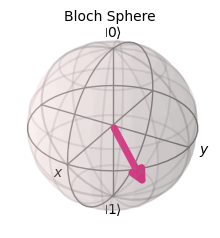

In [7]:
from qiskit.visualization import plot_bloch_vector

plot_bloch_vector([1,1,0], title="Bloch Sphere", figsize=(2,2))
# array of three elements where [<x>, <y>, <z>] (Cartesian) 
# default coord_type is cartesian

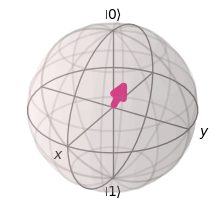

In [8]:
import numpy as np

plot_bloch_vector([1/np.sqrt(2), 1/np.sqrt(3),1], coord_type='spherical', figsize=(2,2))
# [<r>, <theta>, <phi>] (spherical in radians) 
# <theta> is inclination angle from +z direction 
# <phi> is azimuth from +x direction

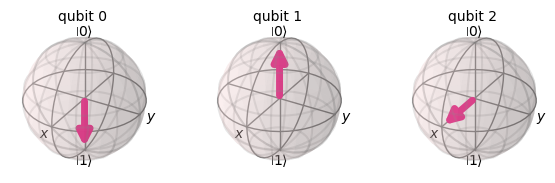

In [9]:
# statevector is a complex vector that describes the state of a quantum system.
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(3)
qc.x(0)
qc.z(1)
qc.h(2)
state = Statevector(qc)

plot_bloch_multivector(state,figsize=[2,2])

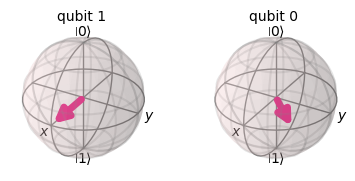

In [10]:
# density matrix is a generalisation of statevector, and can represent mixed states as well as pure states.
from qiskit.quantum_info import DensityMatrix

qc = QuantumCircuit(2)
qc.h([0,1])
qc.t(0)
qc.cx(0,1)

matrix = DensityMatrix(qc)
plot_bloch_multivector(matrix, reverse_bits=True, figsize=[2,2])

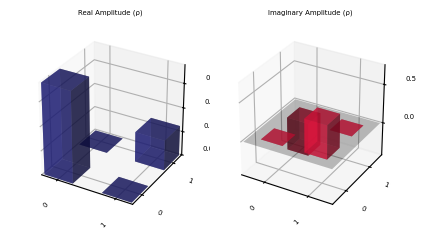

In [11]:
# plot two 3d bar graphs (two dimensional) of the real and imaginary part of the density matrix rho.
from qiskit.visualization import plot_state_city

state = [[ 0.75  , 0.433j],
         [-0.433j, 0.25  ]]
plot_state_city(state, figsize=(4,4), alpha=0.6, color=['midnightblue', 'crimson'])

# a value error occurs if color is not in a tuple of 2. 
# a visualization error occurs if it is not a valid N-qubit state.
# alpha is the transparency of the bars, with 0 being fully transparent and 1 being fully opaque.

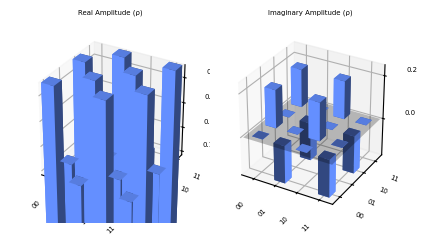

In [12]:
# plot using a Statevector
state = Statevector(qc)
plot_state_city(state, figsize=(4,4))

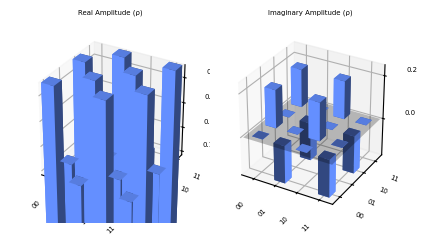

In [13]:
# plot using a DensityMatrix
state = DensityMatrix(qc)
plot_state_city(state, figsize=(4,4))

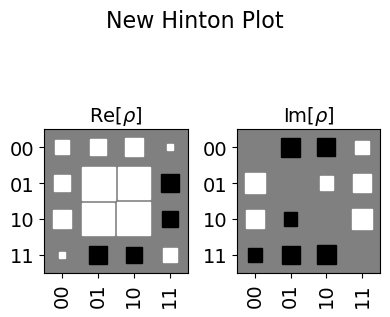

In [14]:
# The hinton diagram represents the values of a matrix using squares, whose size indicate the magnitude of their corresponding value.
# A white square means the value is positive and a black one means negative.
from qiskit.visualization import plot_state_hinton

qc = QuantumCircuit(2)
qc.h([0, 1])
qc.cz(0,1)
qc.ry(np.pi/3 , 0)
qc.rx(np.pi/5, 1)

state = DensityMatrix(qc)
plot_state_hinton(state, title="New Hinton Plot", figsize=(4,4))

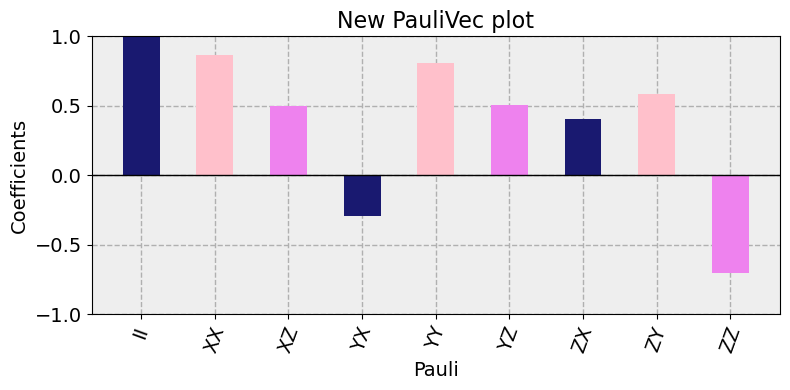

In [15]:
# The Pauli-vector of a density matrix ρ is defined by the expectation of each possible tensor product of single-qubit Pauli operators
# ρ = 1/2^n  ∑ ​σ∈{I,X,Y,Z}⊗n  Tr(σρ)σ
# This function plots the coefficients Tr(σρ) as bar graph.

from qiskit.visualization import plot_state_paulivec

state = Statevector(qc)
plot_state_paulivec(state, color=['midnightblue','pink','violet'], title="New PauliVec plot", figsize=(8,4))

# If you introduce a list with less colors than bars, the color of the bars will alternate following the sequence from the list.

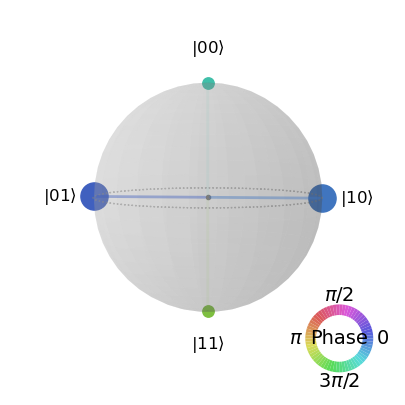

In [16]:
# size of the points is proportional to the probability of the corresponding term in the state and the color represents the phase.
from qiskit.visualization import plot_state_qsphere

state = Statevector(qc)
plot_state_qsphere(state, figsize=(5,5))

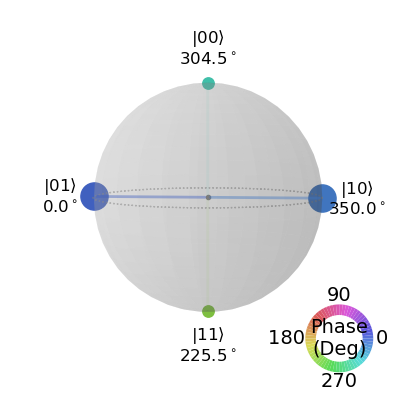

In [17]:
# You can show the phase of each state and use degrees instead of radians
matrix = DensityMatrix(qc)
plot_state_qsphere(matrix,show_state_phases = True, use_degrees = True, figsize=(5,5))

#### Device Visualization - visualize hardware

`plot_gate_map` - plot gate map of device

`plot_error_map` - plot error map of backend

`plot_circuit_layout` - plot layout of circuit transpiled for target backend

`plot_coupling_map` - plot arbitrary coupling map of qubits embedded in plane

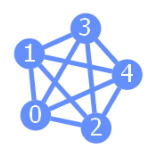

In [18]:
# plot_gate_map() shows the connectivity of the qubits and the gates that can be applied between them.
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_gate_map
backend = GenericBackendV2(num_qubits=5)
plot_gate_map(backend)

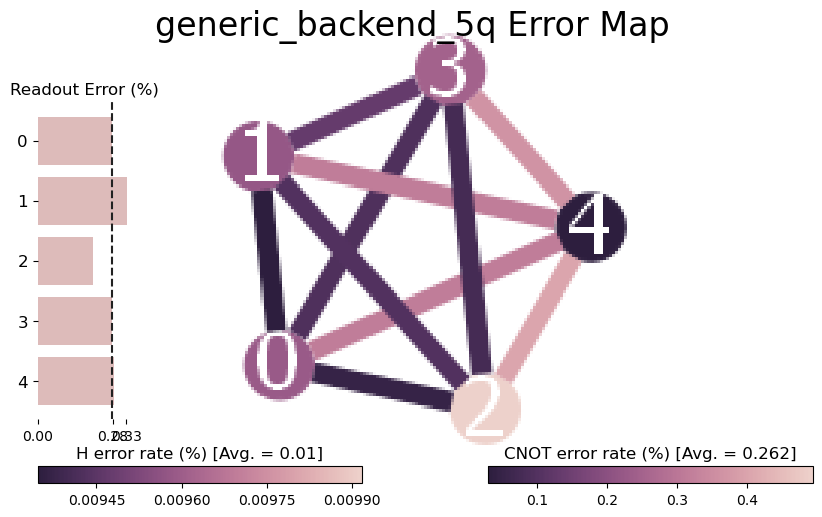

In [19]:
# plot_error_map() shows the error rates of the gates and measurements of a backend.
from qiskit.visualization import plot_error_map
from qiskit.providers.fake_provider import GenericBackendV2
backend = GenericBackendV2(num_qubits=5)
plot_error_map(backend, figsize=(10,6))

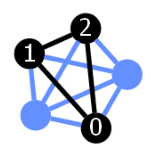

In [20]:
# plot_circuit_layout() shows the layout of the circuit on the backend, and how circuits are mapped to the physical qubits.

from qiskit import QuantumCircuit, transpile
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_circuit_layout

ghz = QuantumCircuit(3, 3)
ghz.h(0)
for idx in range(1,3):
    ghz.cx(0,idx)
ghz.measure(range(3), range(3))

backend = GenericBackendV2(num_qubits=5)
new_circ_lv3 = transpile(ghz, backend=backend, optimization_level=3)
plot_circuit_layout(new_circ_lv3, backend)

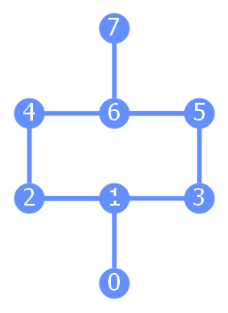

In [32]:
# plot_coupling_map() shows the coupling map of a backend which represents the connectivity of the qubits.

from qiskit.visualization import plot_coupling_map

num_qubits = 8
qubit_coordinates = [[0, 1], [1, 1], [1, 0], [1, 2], [2, 0], [2, 2], [2, 1], [3, 1]]
coupling_map = [[0, 1], [1, 2], [2, 3], [3, 5], [4, 5], [5, 6], [2, 4], [6, 7]]
plot_coupling_map(num_qubits, qubit_coordinates, coupling_map)

#### Circuit Visualization - visualize circuit

`circuit_drawer` - draw quantum circuit

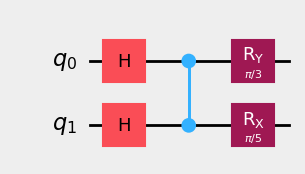

In [22]:
from qiskit.visualization import circuit_drawer
circuit_drawer(qc, output="mpl", style={"backgroundcolor": "#EEEEEE"})

#### DAG Visualization - visualize operation dependecies in quantum circuit

`dag_drawer` - plot directed acyclic graph (dag) to represent operation dependencies in quantum circuit

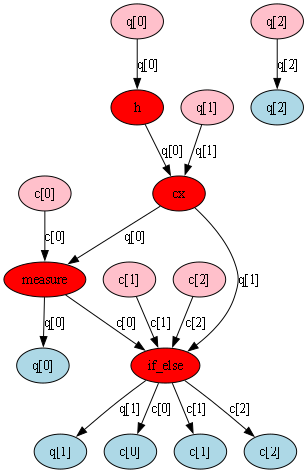

In [23]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit.converters import circuit_to_dag
from qiskit.visualization import dag_drawer

q = QuantumRegister(3, 'q')
c = ClassicalRegister(3, 'c')
circ = QuantumCircuit(q, c)
circ.h(q[0])
circ.cx(q[0], q[1])
circ.measure(q[0], c[0])
with circ.if_test((c, 2)):
    circ.rz(0.5, q[1])

dag = circuit_to_dag(circ)

style = {
    "inputnodecolor": "pink",
    "outputnodecolor": "lightblue",
    "opnodecolor": "red",
}

dag_drawer(dag, style=style)

#### Pass Manager Visualization

`pass_manager_drawer` - draws pass manager

from qiskit import QuantumCircuit

from qiskit.transpiler import generate_preset_pass_manager

from qiskit.visualization import pass_manager_drawer

pm = generate_preset_pass_manager(optimization_level=0)

pass_manager_drawer(pm)

Gives permission error

#### Timeline Visualization

`timeline_drawer` - generate visualize data for scheduled circuit programs

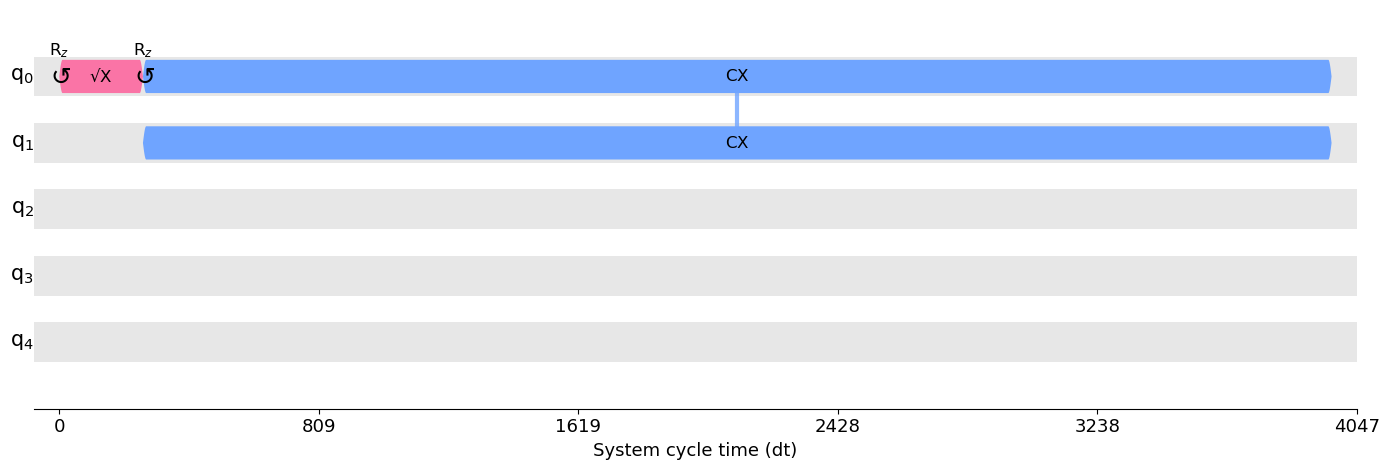

In [24]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization.timeline import draw
from qiskit.providers.fake_provider import GenericBackendV2

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

backend = GenericBackendV2(5)

qc = transpile(qc, backend, scheduling_method='alap', layout_method='trivial')
draw(qc, target=backend.target)

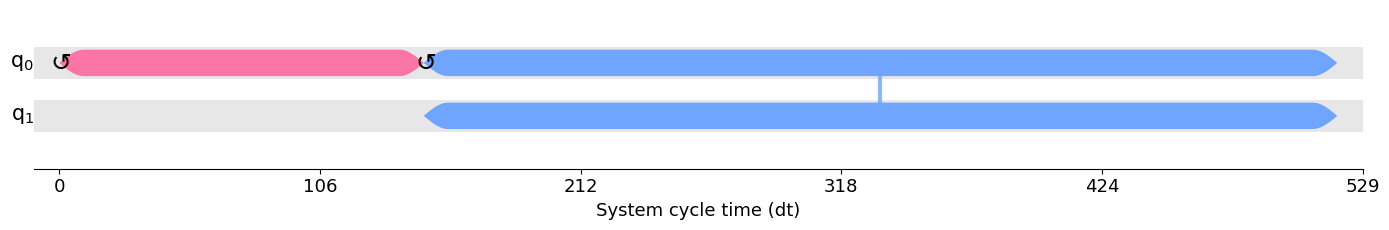

In [25]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization.timeline import draw, IQXSimple
from qiskit.providers.fake_provider import GenericBackendV2

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

backend = GenericBackendV2(5)

qc = transpile(qc, backend, scheduling_method='alap', layout_method='trivial')
draw(qc, style=IQXSimple(), target=backend.target)

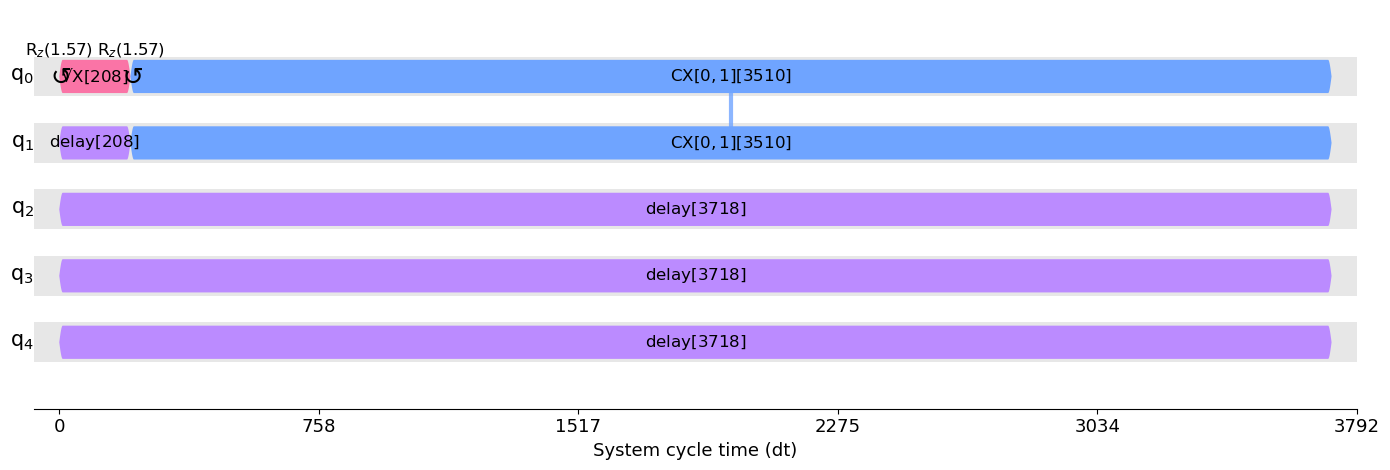

In [26]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization.timeline import draw, IQXDebugging
from qiskit.providers.fake_provider import GenericBackendV2

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

backend = GenericBackendV2(5)
qc = transpile(qc, backend, scheduling_method='alap', layout_method='trivial')
draw(qc, style=IQXDebugging(), target=backend.target)

#### Single Qubit State Transition Visualization

`visualize_transition` - creates animation showing transitions between states of single qubit by applying quantum gates.

The function `qiskit.visualization.transition_visualization.visualize_transition()` is deprecated as of Qiskit 1.2.0. It will be removed in the 2.0 release.

#### Array/Matrix Visualization

`array_to_latex` - latex representation of complex numpy array (dimension 1 or 2)

In [30]:
from qiskit.visualization import array_to_latex
arr = np.array([[1, 2], [3, 4]])
array_to_latex(arr)

<IPython.core.display.Latex object>